### Flow map
Now that we have a grid over the $(a,b)$-plane we can visualize the loss landscape. Below the red dot represents the base parameterization from which all other points are reweighed from. The green start is the target parameterization where the loss function (in this case the psuedo-$\chi^2$) should be at a minimum. The arrow represent the gradients of $a$ and $b$ at each grid point.

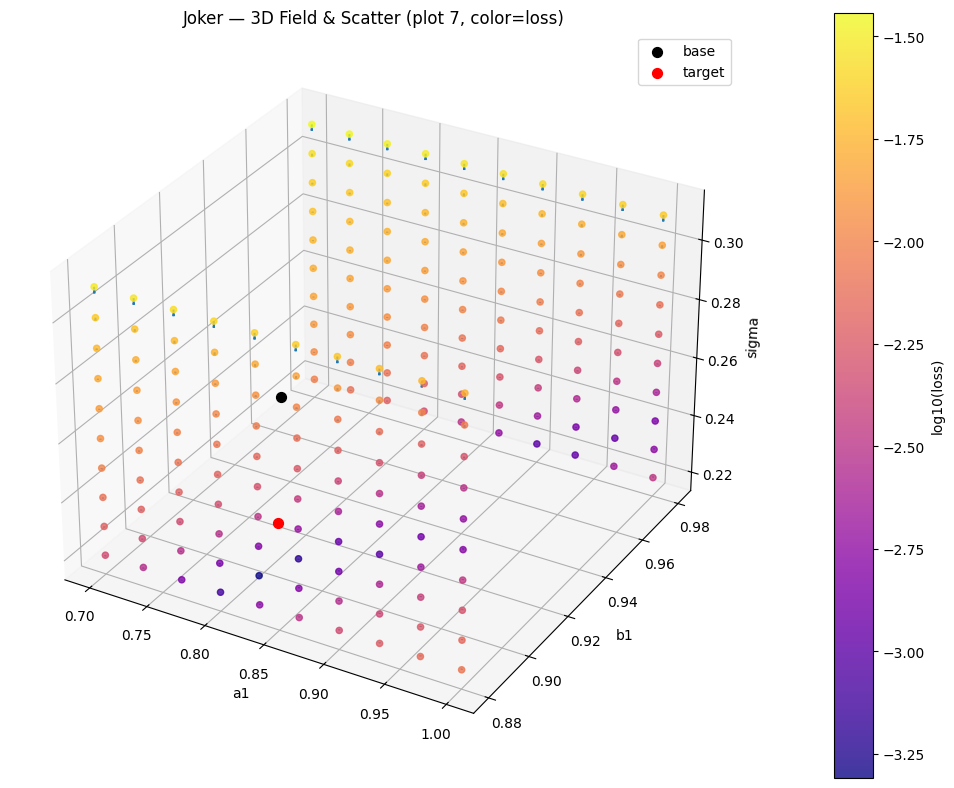

In [1]:
#!/usr/bin/env python3
"""
3D gradient field + scatter coloring with nested configs:
- Outer level keyed by `observable`
- Inner level keyed by `plot_nm`

Choose `observable`, `plot_nm`, and `color_metric` at the top.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - keeps older mpl happy

# =========================
# User choices
# =========================
# observable   = 'mult,charged_mult,p_all_1mom,p_charged_1mom,p_all_var,p_charged_var,p_all_skew,p_charged_skew'   # folder name under temp_results/Flow_map/3D/
observable   = 'Joker'   # folder name under temp_results/Flow_map/3D/
plot_nm      = '7'            # '0', '1', ...
color_metric = 'loss'         # one of: 'Neff', 'loss', 'magnitude'

# =========================
# Configurations per observable (outer) and per plot (inner)
# =========================
plot_configs = {
    'p_all_skew': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'p_all_1mom': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,p_all_skew,p_all_1mom': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,charged_mult,p_all_1mom,p_charged_1mom,p_all_var,p_charged_var,p_all_skew,p_charged_skew': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '3': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,charged_mult': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'Joker': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '3': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '4': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '5': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '6': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '7': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '8': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
    },

    # Add more observables below as needed:
    # 'some_other_observable': {
    #     '0': {...},
    #     '1': {...},
    # },
}

def get_config(obs: str, pnm: str):
    try:
        return plot_configs[obs][pnm]
    except KeyError:
        available = {k: list(v.keys()) for k, v in plot_configs.items()}
        raise ValueError(
            f"No config found for observable='{obs}', plot_nm='{pnm}'. "
            f"Available: {available}"
        )

config = get_config(observable, plot_nm)

# =========================
# Paths
# =========================
base_dir   = os.path.join("temp_results", "Flow_map", "3D", observable)
out_folder = os.path.join("temp_results", "Flow_map_nD", "plots", observable)
os.makedirs(out_folder, exist_ok=True)

# =========================
# Load data
# =========================
gradients      = np.load(os.path.join(base_dir, f'gradients_{plot_nm}.npy'))
magnitudes     = np.load(os.path.join(base_dir, f'magnitudes_{plot_nm}.npy'))
loss_grid      = np.load(os.path.join(base_dir, f'loss_grid_{plot_nm}.npy'))
mu_sigmamu     = np.load(os.path.join(base_dir, f'mu_{plot_nm}.npy'))
Neff           = np.load(os.path.join(base_dir, f'Neff_{plot_nm}.npy'))
params_grid    = np.load(os.path.join(base_dir, f'params_grid_{plot_nm}.npy'))
ordered_params = np.load(os.path.join(base_dir, f'ordered_params_{plot_nm}.npy'))

# Ensure ordered_params are strings (handle bytes from npy if present)
def _to_str_list(arr):
    out = []
    for x in np.atleast_1d(arr):
        if isinstance(x, bytes):
            out.append(x.decode('utf-8', errors='ignore'))
        else:
            out.append(str(x))
    return out

ordered_params = _to_str_list(ordered_params)

# Unpack useful pieces
mu, sigmamu = mu_sigmamu[:, 0], mu_sigmamu[:, 1]
p1, p2, p3  = params_grid[:, 0], params_grid[:, 1], params_grid[:, 2]

# Descent direction = negative gradient
g1, g2, g3 = -gradients[:, 0], -gradients[:, 1], -gradients[:, 2]

# =========================
# Choose coloring metric
# =========================
if color_metric == 'Neff':
    c_vals = Neff
    c_label = 'Neff'
elif color_metric == 'loss':
    c_vals = np.log10(loss_grid)
    c_label = 'log10(loss)'
elif color_metric == 'magnitude':
    # If your saved "magnitudes" already represent |grad| or any scalar field:
    c_vals = magnitudes
    c_label = 'magnitude'
else:
    raise ValueError("color_metric must be one of: 'Neff', 'loss', 'magnitude'.")

# =========================
# Plot
# =========================
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Base & target
ax.scatter(*config['base'],   marker='o', color='black', s=50, label='base')
ax.scatter(*config['target'], marker='o', color='red',   s=50, label='target')

# Quiver for gradient field (scaled)
ax.quiver(
    p1, p2, p3,
    g1 / config['scale'],
    g2 / config['scale'],
    g3 / config['scale'],
    length=1.0, normalize=False
)

# Scatter colored by selected metric
sc = ax.scatter(p1, p2, p3, c=c_vals, cmap='plasma', s=20, alpha=0.8)
cbar = fig.colorbar(sc, pad=0.1)
cbar.set_label(c_label)

# Labels & title
ax.set_xlabel(ordered_params[0])
ax.set_ylabel(ordered_params[1])
ax.set_zlabel(ordered_params[2])
ax.set_title(f'{observable} — 3D Field & Scatter (plot {plot_nm}, color={color_metric})')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


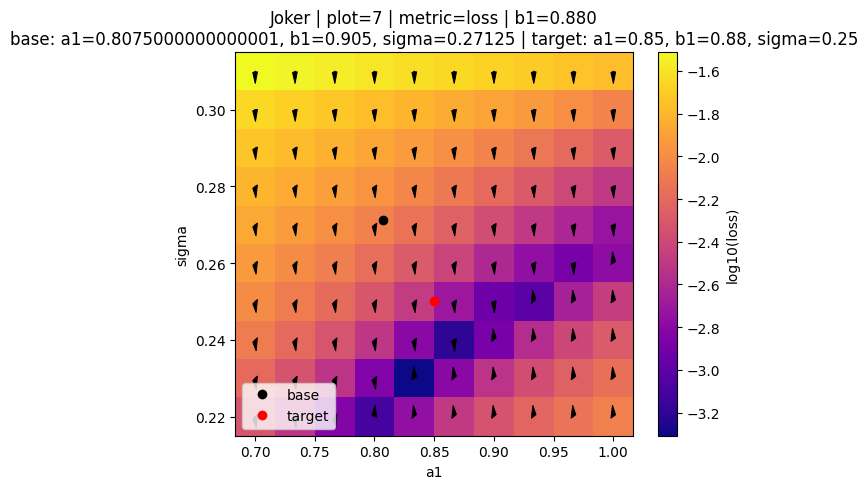

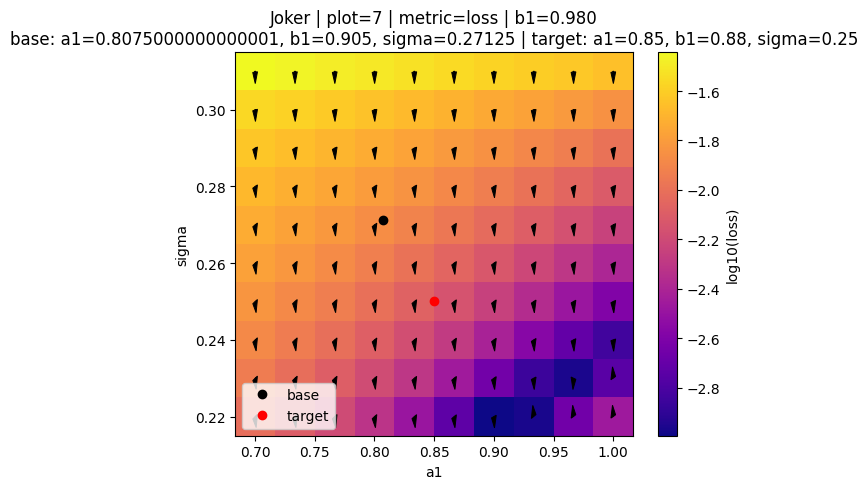

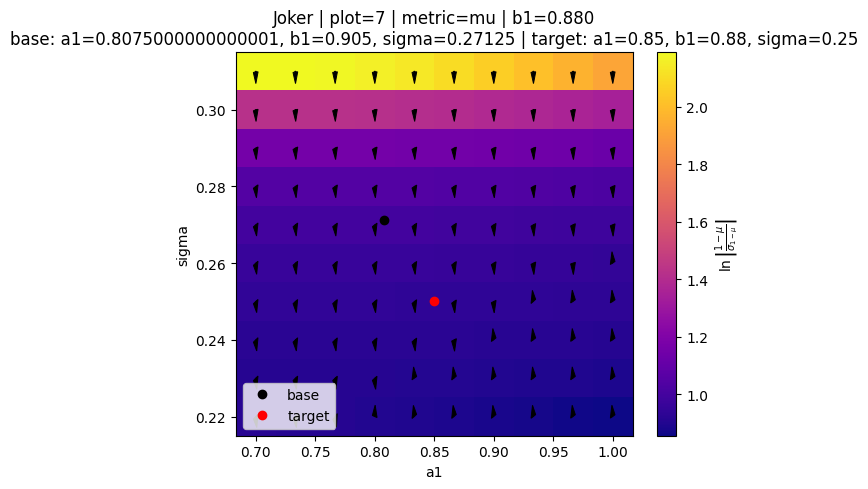

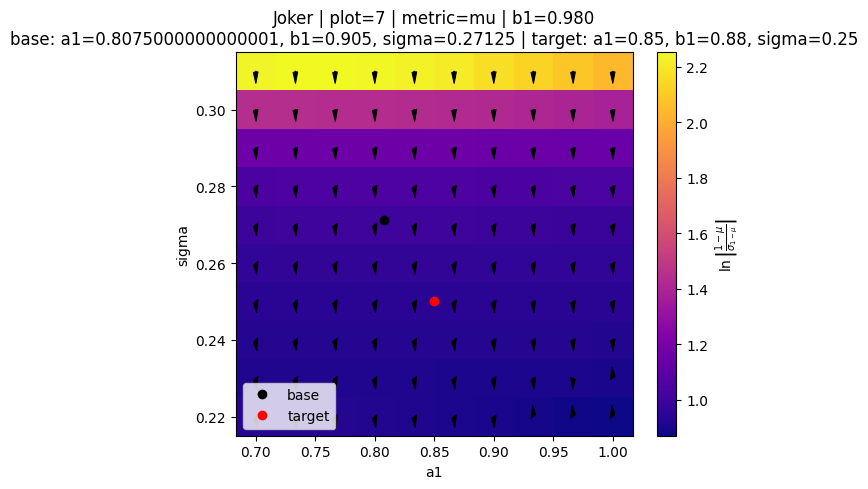

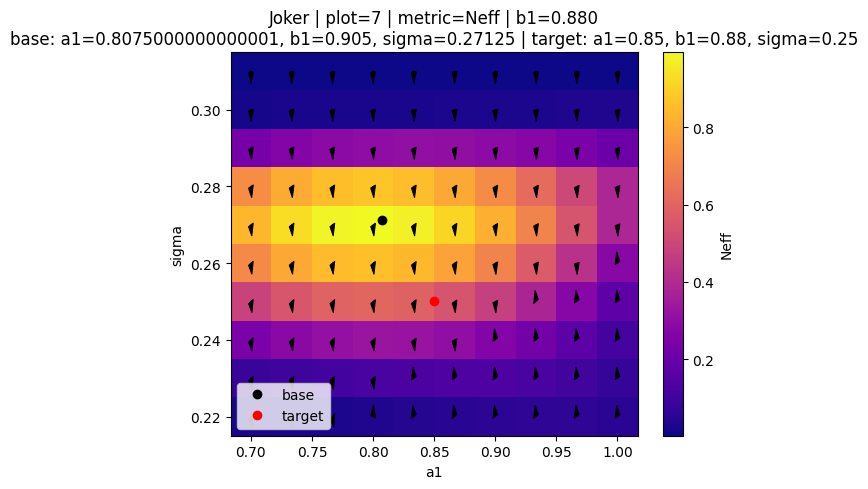

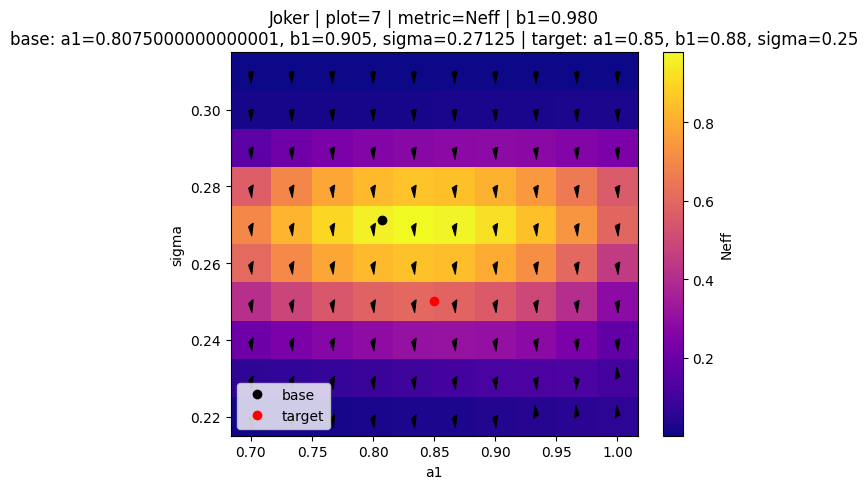

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Choose observable & plot
# =========================
# observable = 'p_all_1mom'   # <-- set this
# plot_nm    = '1'            # <-- and this ('0', '1', ...)

# =========================
# Configurations per observable (outer) and per plot (inner)
# =========================
plot_configs = {
    'p_all_skew': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'p_all_1mom': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,p_all_skew,p_all_1mom': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,charged_mult,p_all_1mom,p_charged_1mom,p_all_var,p_charged_var,p_all_skew,p_charged_skew': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '3': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,charged_mult': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'Joker': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '3': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '4': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '5': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '6': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '7': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '8': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
    },

    # Add more observables below as needed:
    # 'some_other_observable': {
    #     '0': {...},
    #     '1': {...},
    # },
}

def get_config(obs: str, pnm: str):
    try:
        return plot_configs[obs][pnm]
    except KeyError:
        raise ValueError(f"No config found for observable='{obs}', plot_nm='{pnm}'. "
                         f"Available: {list(plot_configs.keys())}")

config = get_config(observable, plot_nm)

# =========================
# Paths (centralized)
# =========================
base_dir = f"temp_results/Flow_map/3D/{observable}"
out_folder = f"temp_results/Flow_map_nD/plots/{observable}"
os.makedirs(out_folder, exist_ok=True)

# =========================
# Load data
# =========================
gradients      = np.load(os.path.join(base_dir, f'gradients_{plot_nm}.npy'))
loss_grid      = np.load(os.path.join(base_dir, f'loss_grid_{plot_nm}.npy'))
mu_sigmamu     = np.load(os.path.join(base_dir, f'mu_{plot_nm}.npy'))
Neff           = np.load(os.path.join(base_dir, f'Neff_{plot_nm}.npy'))
params_grid    = np.load(os.path.join(base_dir, f'params_grid_{plot_nm}.npy'))
ordered_params = np.load(os.path.join(base_dir, f'ordered_params_{plot_nm}.npy'))

# Ensure ordered_params are strings (handle bytes from npy if present)
def _to_str_list(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode('utf-8', errors='ignore'))
        else:
            out.append(str(x))
    return out

ordered_params = _to_str_list(ordered_params)

# Unpack weight metrics
mu, sigmamu = mu_sigmamu[:, 0], mu_sigmamu[:, 1]

# =========================
# Metrics to display
# =========================
metrics = {
    'loss': {
        'values': lambda: np.log10(loss_grid),
        'label':  'log10(loss)'
    },
    'mu':   {
        'values': lambda: mu,
        'label':  r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"
    },
    'Neff': {
        'values': lambda: Neff,
        'label':  'Neff'
    },
}

# =========================
# Slice along the middle parameter (bd = params_grid[:,1])
# =========================
bds = np.unique(params_grid[:, 1])

last_Z = None
last_dx = None
last_dz = None

for metric_key, metric in metrics.items():
    vals = metric['values']()
    for bd_val in bds:
        mask    = (params_grid[:, 1] == bd_val)
        p0_vals = params_grid[mask, 0]   # a_d (first param)
        p2_vals = params_grid[mask, 2]   # sigma (third param)
        grads   = gradients[mask]
        m_vals  = vals[mask]

        # Build rectangular grid in (a_d, sigma)
        a_u  = np.unique(p0_vals)
        s_u  = np.unique(p2_vals)
        A, S = np.meshgrid(a_u, s_u, indexing='ij')

        # Safety check: ensure reshaping is consistent
        expected_size = len(a_u) * len(s_u)
        if m_vals.size != expected_size:
            raise ValueError(
                f"Inconsistent grid for bd={bd_val}: metric values size={m_vals.size}, "
                f"expected {expected_size} (len(a_u)={len(a_u)} * len(s_u)={len(s_u)})."
            )

        Z = m_vals.reshape(len(a_u), len(s_u))

        # Plot heatmap
        plt.figure(figsize=(6, 5))
        pcm = plt.pcolormesh(A, S, Z, shading='auto', cmap='plasma')
        plt.colorbar(pcm, label=metric['label'])

        # Overlay gradient arrows (negative = descent direction)
        for (x, z), g in zip(np.vstack([p0_vals, p2_vals]).T, grads):
            dx = -g[0] / config['scale']
            dz = -g[2] / config['scale']
            plt.arrow(
                x, z, dx, dz,
                head_width=config['head_width'],
                head_length=config['head_length'],
                fc='k', ec='k', linewidth=0.7
            )
            last_dx, last_dz = dx, dz  # keep last for printing

        # Mark base & target
        bx, by, bz = config['base']
        tx, ty, tz = config['target']
        plt.plot(bx, bz, 'o', color='black', markersize=6, label='base')
        plt.plot(tx, tz, 'o', color='red',   markersize=6, label='target')

        # Titles and labels
        title = (
            f"{observable} | plot={plot_nm} | metric={metric_key} | {ordered_params[1]}={bd_val:.3f}\n"
            f"base: {ordered_params[0]}={bx}, {ordered_params[1]}={by}, {ordered_params[2]}={bz} | "
            f"target: {ordered_params[0]}={tx}, {ordered_params[1]}={ty}, {ordered_params[2]}={tz}"
        )
        plt.title(title)
        plt.xlabel(ordered_params[0])
        plt.ylabel(ordered_params[2])
        plt.legend(loc='lower left')
        plt.tight_layout()

        # Save
        fname = f'{observable}_plot{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png'
        plt.savefig(os.path.join(out_folder, fname), dpi=300, bbox_inches='tight')
        # plt.close()

        # Keep last Z for printing
        last_Z = Z

# Optional debug prints (last computed grid and last arrow components)
# if last_Z is not None:
#     print(last_Z)
# if (last_dx is not None) and (last_dz is not None):
#     print(last_dx, last_dz)


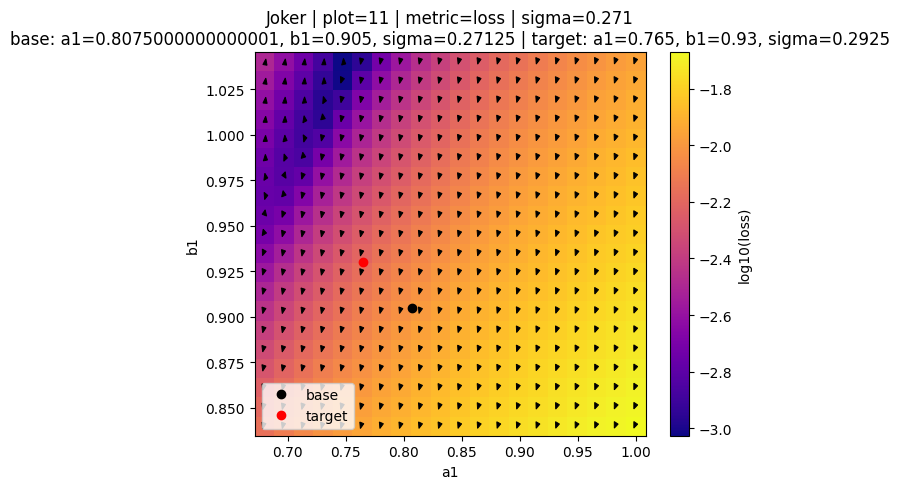

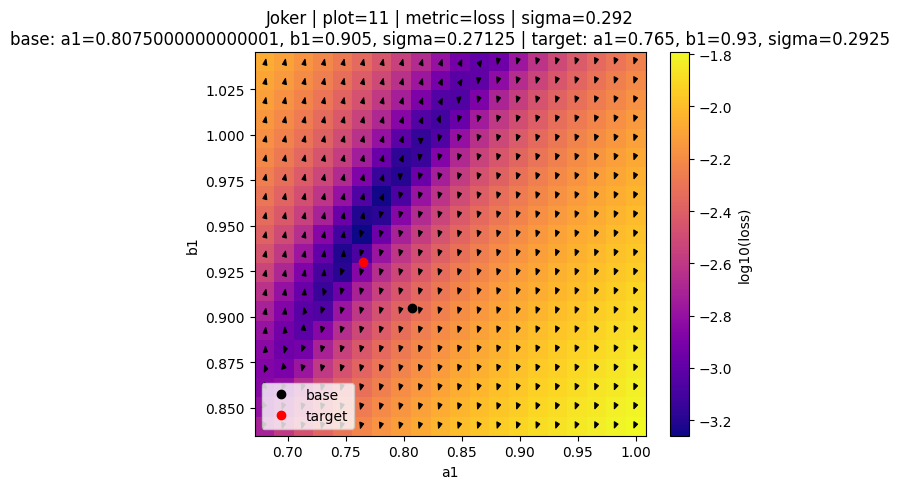

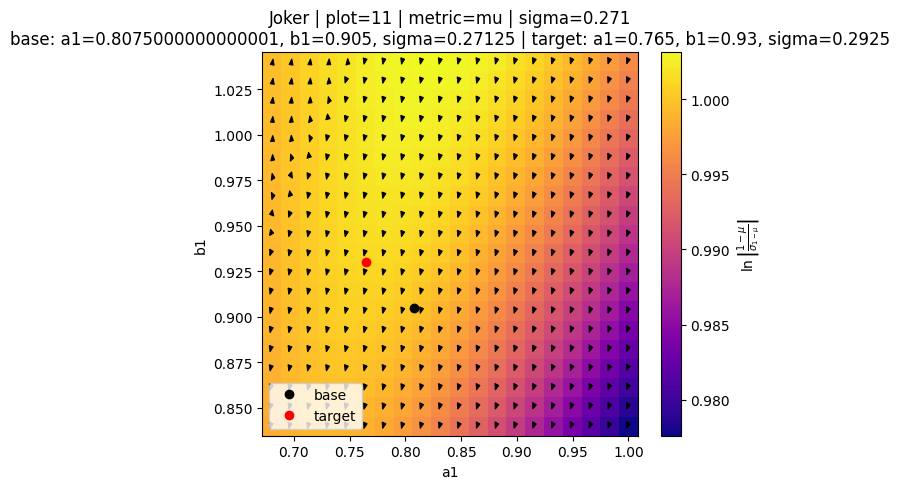

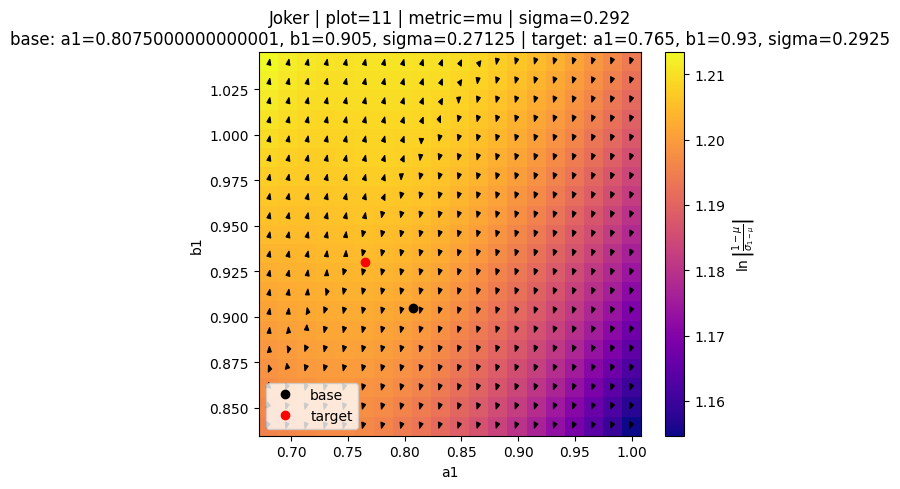

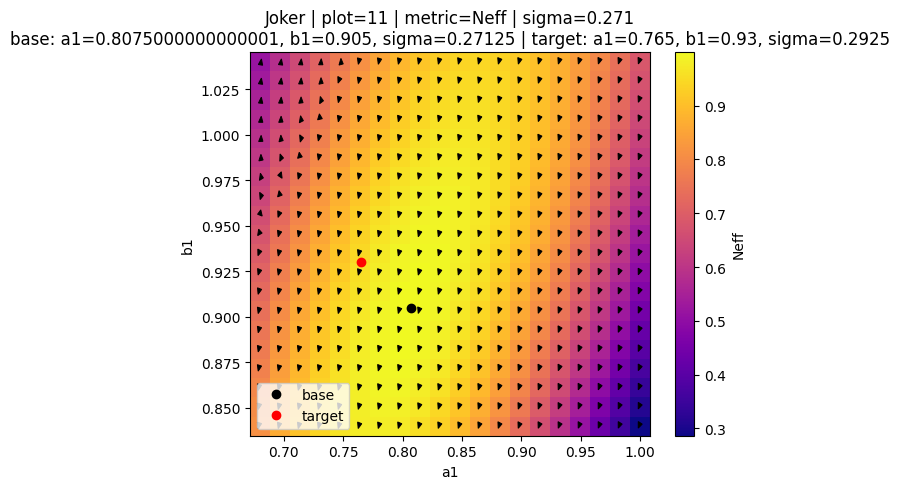

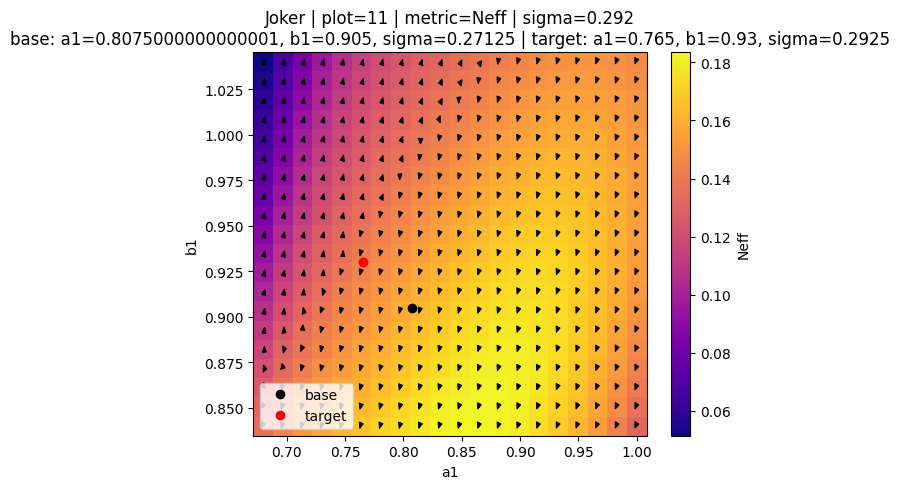

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Choose observable & plot
# =========================
observable = 'Joker'   # <-- set this
plot_nm    = '11'            # <-- and this ('0', '1', ...)

# =========================
# Configurations per observable (outer) and per plot (inner)
# =========================
plot_configs = {
    'p_all_skew': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'p_all_1mom': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,p_all_skew,p_all_1mom': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,charged_mult,p_all_1mom,p_charged_1mom,p_all_var,p_charged_var,p_all_skew,p_charged_skew': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '3': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'mult,charged_mult': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'Joker': {
        '0': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '2': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '3': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '4': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '5': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '6': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '7': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '8': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '9': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.85,          0.88,  0.25),
        },
        '10': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.68 + 0.085,          0.93,  0.2925),
        },
        '11': {
            'scale': 6e3,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.1275, 0.905, 0.27125),
            'target': (0.68 + 0.085,          0.93,  0.2925),
        },
    },
}

def get_config(obs: str, pnm: str):
    try:
        return plot_configs[obs][pnm]
    except KeyError:
        raise ValueError(f"No config found for observable='{obs}', plot_nm='{pnm}'. "
                         f"Available: {list(plot_configs.keys())}")

config = get_config(observable, plot_nm)

# =========================
# Paths (centralized)
# =========================
base_dir = f"temp_results/Flow_map/3D/{observable}"
out_folder = f"temp_results/Flow_map_nD/plots/{observable}"
os.makedirs(out_folder, exist_ok=True)

# =========================
# Load data
# =========================
gradients      = np.load(os.path.join(base_dir, f'gradients_{plot_nm}.npy'))
loss_grid      = np.load(os.path.join(base_dir, f'loss_grid_{plot_nm}.npy'))
mu_sigmamu     = np.load(os.path.join(base_dir, f'mu_{plot_nm}.npy'))
Neff           = np.load(os.path.join(base_dir, f'Neff_{plot_nm}.npy'))
params_grid    = np.load(os.path.join(base_dir, f'params_grid_{plot_nm}.npy'))
ordered_params = np.load(os.path.join(base_dir, f'ordered_params_{plot_nm}.npy'))

def _to_str_list(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode('utf-8', errors='ignore'))
        else:
            out.append(str(x))
    return out

ordered_params = _to_str_list(ordered_params)
mu, sigmamu = mu_sigmamu[:, 0], mu_sigmamu[:, 1]

# =========================
# Metrics
# =========================
metrics = {
    'loss': {
        'values': lambda: np.log10(loss_grid),
        'label':  'log10(loss)'
    },
    'mu':   {
        'values': lambda: mu,
        'label':  r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"
    },
    'Neff': {
        'values': lambda: Neff,
        'label':  'Neff'
    },
}

# =========================
# Slice along sigma (3rd param), plot a vs b
# =========================
sigma_vals = np.unique(params_grid[:, 2])

last_Z = None
last_dx = None
last_dy = None

for metric_key, metric in metrics.items():
    vals = metric['values']()
    for sigma_val in sigma_vals:
        mask    = (params_grid[:, 2] == sigma_val)
        p0_vals = params_grid[mask, 0]   # a_d (first param)
        p1_vals = params_grid[mask, 1]   # b_d (second param)
        grads   = gradients[mask]
        m_vals  = vals[mask]

        # Build rectangular grid in (a_d, b_d)
        a_u  = np.unique(p0_vals)
        b_u  = np.unique(p1_vals)
        A, B = np.meshgrid(a_u, b_u, indexing='ij')

        expected_size = len(a_u) * len(b_u)
        if m_vals.size != expected_size:
            raise ValueError(
                f"Inconsistent grid for sigma={sigma_val}: metric values size={m_vals.size}, "
                f"expected {expected_size} (len(a_u)={len(a_u)} * len(b_u)={len(b_u)})."
            )

        Z = m_vals.reshape(len(a_u), len(b_u))

        # Plot heatmap
        plt.figure(figsize=(6, 5))
        pcm = plt.pcolormesh(A, B, Z, shading='auto', cmap='plasma')
        plt.colorbar(pcm, label=metric['label'])

        # Overlay gradient arrows (negative = descent direction)
        for (x, y), g in zip(np.vstack([p0_vals, p1_vals]).T, grads):
            dx = -g[0] / config['scale']
            dy = -g[1] / config['scale']
            plt.arrow(
                x, y, dx, dy,
                head_width=config['head_width'],
                head_length=config['head_length'],
                fc='k', ec='k', linewidth=0.7
            )
            last_dx, last_dy = dx, dy

        # Mark base & target
        bx, by, bz = config['base']
        tx, ty, tz = config['target']
        plt.plot(bx, by, 'o', color='black', markersize=6, label='base')
        plt.plot(tx, ty, 'o', color='red',   markersize=6, label='target')

        # Titles and labels
        title = (
            f"{observable} | plot={plot_nm} | metric={metric_key} | {ordered_params[2]}={sigma_val:.3f}\n"
            f"base: {ordered_params[0]}={bx}, {ordered_params[1]}={by}, {ordered_params[2]}={bz} | "
            f"target: {ordered_params[0]}={tx}, {ordered_params[1]}={ty}, {ordered_params[2]}={tz}"
        )
        plt.title(title)
        plt.xlabel(ordered_params[0])
        plt.ylabel(ordered_params[1])
        plt.legend(loc='lower left')
        plt.tight_layout()

        # Save
        fname = f'{observable}_plot{plot_nm}_{metric_key}_sigma_{sigma_val:.5f}.png'
        plt.savefig(os.path.join(out_folder, fname), dpi=300, bbox_inches='tight')

        last_Z = Z
